In [3]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [4]:
import os, sys, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DATA_DIR = "data"
OUTPUT_DIR = "clean_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data dir   : {os.path.abspath(DATA_DIR)}")
print(f"Output dir : {os.path.abspath(OUTPUT_DIR)}")

Data dir   : d:\Text-Summerization-System\data
Output dir : d:\Text-Summerization-System\clean_data


## Load & Raw Data Exploration

In [5]:
splits = ["train", "validation", "test"]
raw = {}
for s in splits:
    path = os.path.join(DATA_DIR, f"{s}.csv")
    raw[s] = pd.read_csv(path)
    print(f"[{s:>10}]  rows={len(raw[s]):>7,}  cols={list(raw[s].columns)}")

[     train]  rows=287,113  cols=['id', 'article', 'highlights']
[validation]  rows= 13,368  cols=['id', 'article', 'highlights']
[      test]  rows= 11,490  cols=['id', 'article', 'highlights']


In [6]:
raw["train"].head(3)

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."


In [7]:
raw["train"].dtypes

id            str
article       str
highlights    str
dtype: object

In [8]:
null_summary = pd.DataFrame({
    s: raw[s].isnull().sum() for s in splits
}).T
print("── Null counts ──")
print(null_summary)

── Null counts ──
            id  article  highlights
train        0        0           0
validation   0        0           0
test         0        0           0


In [9]:
for s in splits:
    dupes = raw[s].duplicated(subset=["id"]).sum()
    print(f"[{s}] duplicate IDs: {dupes}")

[train] duplicate IDs: 0
[validation] duplicate IDs: 0
[test] duplicate IDs: 0


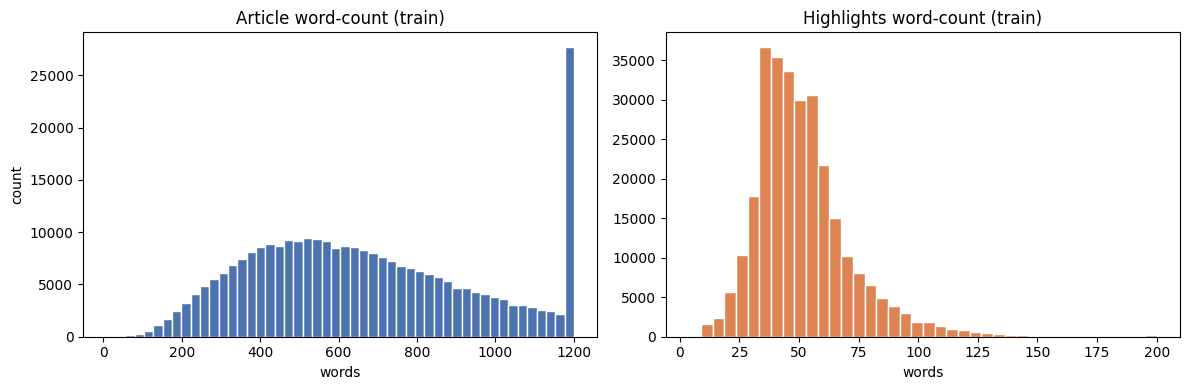

Article  — mean: 692  median: 632  max: 2347
Highlight— mean: 52  median: 48  max: 1296


In [10]:
train_art_wc  = raw["train"]["article"].dropna().str.split().str.len()
train_high_wc = raw["train"]["highlights"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_art_wc.clip(upper=1200), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Article word-count (train)")
axes[0].set_xlabel("words"); axes[0].set_ylabel("count")

axes[1].hist(train_high_wc.clip(upper=200), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Highlights word-count (train)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_distribution.png"), dpi=120)
plt.show()
print(f"Article  — mean: {train_art_wc.mean():.0f}  median: {train_art_wc.median():.0f}  max: {train_art_wc.max()}")
print(f"Highlight— mean: {train_high_wc.mean():.0f}  median: {train_high_wc.median():.0f}  max: {train_high_wc.max()}")

## Data Cleaning
| Step | Action |
|------|--------|
| 1 | Drop rows where `article` **or** `highlights` is null |
| 2 | Strip leading/trailing whitespace |
| 3 | Drop empty strings after strip |
| 4 | Deduplicate by `id` |
| 5 | Filter by word-count thresholds |

In [11]:
MIN_ARTICLE_WORDS    = 30
MIN_HIGHLIGHTS_WORDS = 5
MAX_ARTICLE_WORDS    = 2_000

def clean_df(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    tag = f"[{label}] " if label else ""
    orig = len(df)
    
    # 1. Drop nulls
    df = df.dropna(subset=["article", "highlights"])
    
    # 2. Strip whitespace
    df["article"]    = df["article"].str.strip()
    df["highlights"] = df["highlights"].str.strip()
    
    # 3. Drop empty strings
    df = df[(df["article"].str.len() > 0) & (df["highlights"].str.len() > 0)]
    
    # 4. Deduplicate
    df = df.drop_duplicates(subset=["id"])
    
    # 5. Word-count filter
    aw = df["article"].str.split().str.len()
    hw = df["highlights"].str.split().str.len()
    df = df[(aw >= MIN_ARTICLE_WORDS) & (aw <= MAX_ARTICLE_WORDS) & (hw >= MIN_HIGHLIGHTS_WORDS)]
    
    df = df.reset_index(drop=True)
    print(f"{tag}  {orig:>7,} → {len(df):>7,} rows  (removed {orig-len(df):,})")
    return df

clean = {}
print("Split          raw      clean    removed")
print("─" * 44)
for s in splits:
    clean[s] = clean_df(raw[s].copy(), label=s)


Split          raw      clean    removed
────────────────────────────────────────────
[train]   287,113 → 287,094 rows  (removed 19)
[validation]    13,368 →  13,368 rows  (removed 0)
[test]    11,490 →  11,490 rows  (removed 0)


## Verify Cleaned Data

In [12]:
verify = pd.DataFrame({
    s: {
        "rows":           len(clean[s]),
        "nulls_article":  clean[s]["article"].isnull().sum(),
        "nulls_highlights":clean[s]["highlights"].isnull().sum(),
        "duplicates":     clean[s].duplicated(subset=["id"]).sum(),
        "avg_art_words":  round(clean[s]["article"].str.split().str.len().mean(),1),
        "avg_high_words": round(clean[s]["highlights"].str.split().str.len().mean(),1),
    }
    for s in splits
}).T
verify

KeyboardInterrupt: 

## Visualization Of Cleaned Data

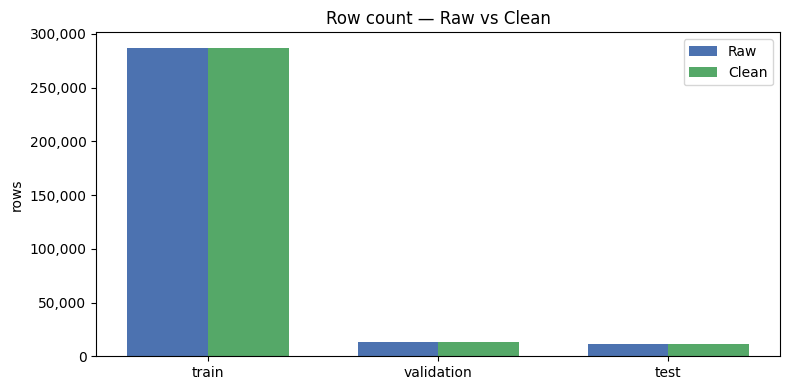

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(splits))
w = 0.35
ax.bar([i - w/2 for i in x], [len(raw[s]) for s in splits],  width=w, label="Raw",   color="#4C72B0")
ax.bar([i + w/2 for i in x], [len(clean[s]) for s in splits], width=w, label="Clean", color="#55A868")
ax.set_xticks(list(x)); ax.set_xticklabels(splits)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_title("Row count — Raw vs Clean"); ax.set_ylabel("rows"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_vs_clean.png"), dpi=120)
plt.show()


## Save Clean CSVs

In [13]:
for s in splits:
    out = os.path.join(OUTPUT_DIR, f"clean_{s}.csv")
    clean[s].to_csv(out, index=False)
    print(f"Saved → {out}  ({len(clean[s]):,} rows)")

Saved → clean_data\clean_train.csv  (287,094 rows)
Saved → clean_data\clean_validation.csv  (13,368 rows)
Saved → clean_data\clean_test.csv  (11,490 rows)
